Autor: Joseph DATE-MASSE

## (EDA)

Dans cette phase, nous cherchons à comprendre :  
1. **Qui part ?** (Analyse des taux de Churn par caractéristiques)  
2. **Pourquoi ?** (Identification des variables les plus corrélées au départ)

La logique visuelle est externalisée dans `src/visualisation.py`.

In [ ]:
import sys
from pathlib import Path
import pandas as pd

src_path = Path.cwd().parent / "src"
sys.path.append(str(src_path))

from utils import setup_logger, ensure_directory_exists
from data_loading import load_data
from visualisation import (
    plot_churn_distribution,
    plot_tenure_distribution,
    plot_churn_by_category,
    plot_numeric_distributions_by_churn,
    plot_correlation_matrix
)


#confi du looger
logger = setup_logger("../reports/logs/data_cleaning.log")

In [3]:
DATA_PATH = str(Path.cwd().parent / "data" / "processed" / "churn_cleaned.csv")
df = load_data(DATA_PATH)

print("\nAppercu de la churn_data_cleaned: ")
df.head()

2026-04-09 05:11:36,998 - INFO - |==> Chargement des données depuis e:\Certifs\Future_Interns\FUTURE_DS_02\data\processed\churn_cleaned.csv



Appercu de la churn_data_cleaned: 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0-6 mois
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,2-3 ans
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0-6 mois
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,3-4 ans
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,0-6 mois


## 1. Distribution Globale
Il est important de savoir quel est le taux de désabonnement global pour avoir un point de référence.

2026-04-09 05:11:41,961 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-09 05:11:41,970 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\churn_distribution.png


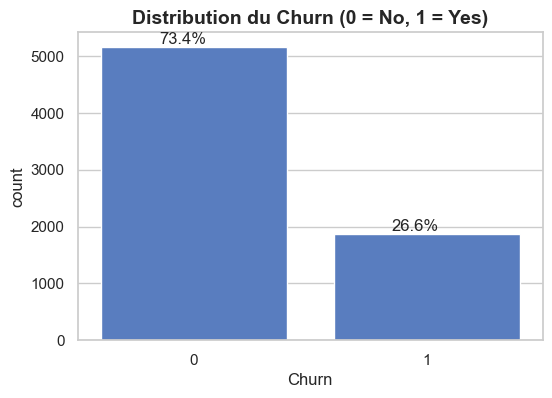

In [4]:
plot_churn_distribution(df)

Ce graphique montre simplement la proportion de clients qui partent `(1)` par rapport à ceux qui restent `(0)`

>En analysant la distribution globale, on remarque qu'environ `26,6 %` de nos clients se désabonnent. Dans le domaine des abonnements, c'est un taux énorme. Une entreprise saine vise souvent un churn de moins de `5 à 10 %`. Cela confirme que l'entreprise a une véritable `'hémorragie'` de clients et que notre mission d'identifier les causes est critique pour sauver le chiffre d'affaires.

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\tenure_distribution.png


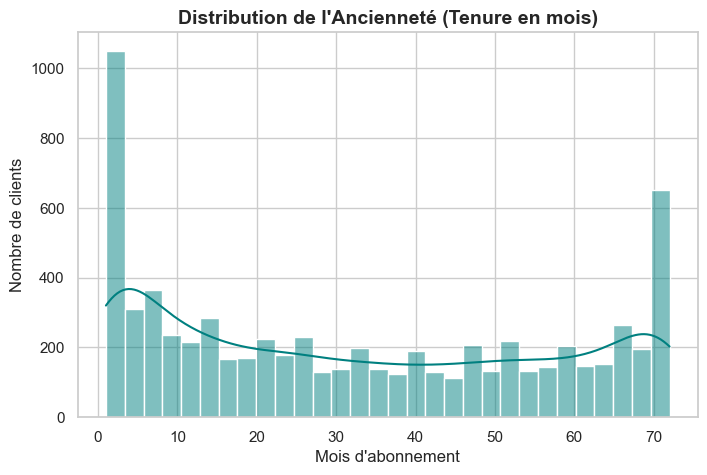

In [5]:
plot_tenure_distribution(df)

Ce graphique ressemble à un histogramme (avec des barres) qui montre à quel mois l'entreprise a le plus de clients.

L'histogramme de l'ancienneté a une forme atypique en 'U' avec deux immenses pics aux extrémités :

 1. Un pic gigantesque dans les tout premiers mois (0-5 mois) : Cela nous indique qu'une grande partie des clients fuit presque immédiatement après avoir souscrit. Il y a probablement un problème grave lors de l'intégration (onboarding), un service décevant au premier abord, ou beaucoup de clients qui viennent juste profiter d'un mois gratuit.

 2. Un autre grand pic à plus de 70 mois : Heureusement, nous avons aussi un noyau très solide de clients extrêmement fidèles qui sont là depuis des années.

> Le constat est clair : Si l'entreprise arrive à faire passer le cap des premiers mois critiques à un client, il y a de fortes chances qu'il reste très longtemps. Notre stratégie de rétention doit donc se focaliser massivement sur les 6 premiers mois

## 2. Analyse Bivariée : Churn vs Catégories (Contrat, Internet, etc.)
On observe quels sont les segments qui ont le taux de désabonnement le plus fort.

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\churn_by_Contract.png


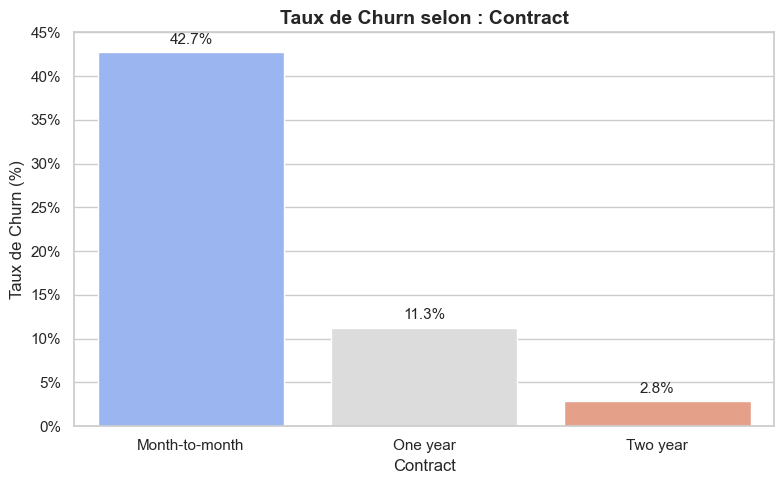

In [6]:
# Analyser l'impact du type de contrat, de la méthode de paiement et du service internet
plot_churn_by_category(df, 'Contract')

Le type de contrat est le facteur prédictif le plus fort du désabonnement.

- Les clients avec un abonnement **Mois par Mois (Month-to-month)** ont un taux de churn extrêmement élevé `(>40%)`.
- À l'inverse, les clients engagés sur 1 ou 2 ans sont extrêmement fidèles `(churn < 10%)`.
> Recommandation : Proposer une réduction agressive ou faire des promo au 3ème mois pour pousser les clients à s'engager sur un an.

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\churn_by_InternetService.png


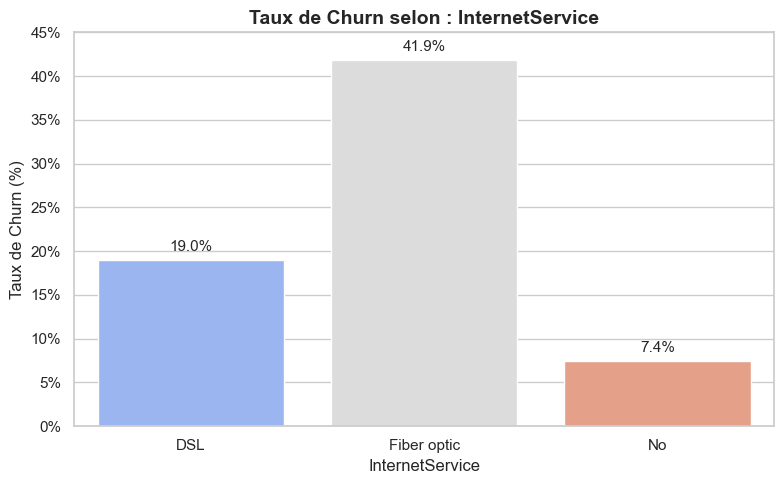

In [13]:
plot_churn_by_category(df, 'InternetService')

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\churn_by_PaymentMethod.png


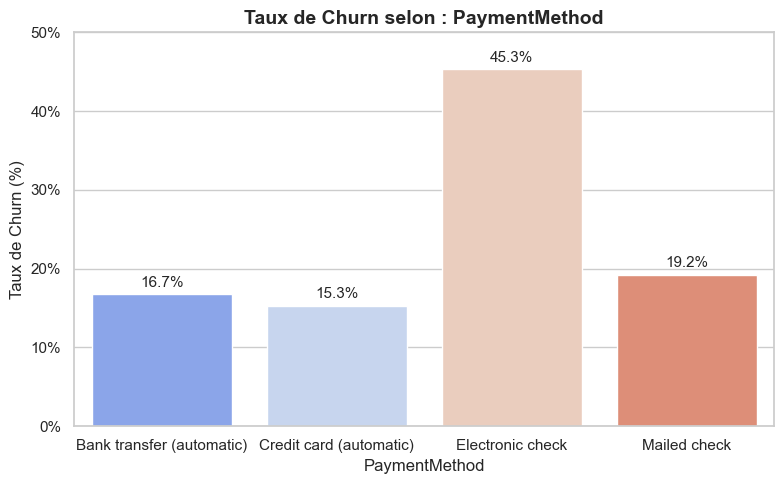

In [14]:
plot_churn_by_category(df, 'PaymentMethod')

Étonnamment, la Fibre Optique subit un churn plus élevé que le DSL (problème d'infrastructure ou de coût perçu ?). De plus, les clients payant manuellement (Electronic check) partent beaucoup plus.

>Imposer ou récompenser fortement la mise en place d'un prélèvement automatique lors de la souscription.

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\churn_by_tenure_group.png


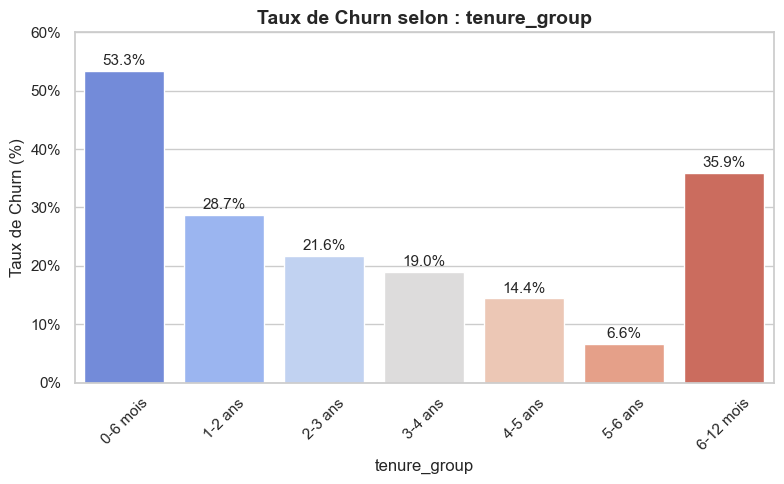

In [9]:
plot_churn_by_category(df, 'tenure_group')

La "Période Critique". La majorité absolue de nos pertes se produit lors des `6 premiers mois`. Si un client passe le cap des `12 mois`, sa probabilité de départ s'effondre.

>Concentrer le budget de Fidélisation (appels clients, cadeaux, aide) uniquement sur les tout nouveaux clients.

## 3. Analyse Financière
L'impact financier : les clients qui paient plus cher partent-ils plus vite ?

2026-04-09 05:18:43,104 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-09 05:18:43,112 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\numeric_dist_MonthlyCharges.png


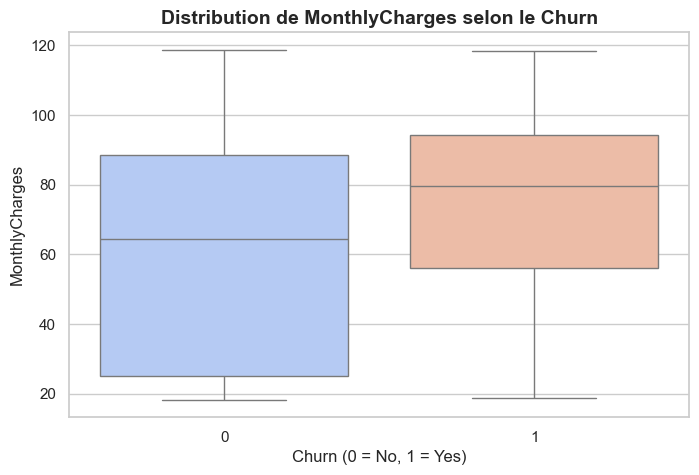

In [10]:
plot_numeric_distributions_by_churn(df, 'MonthlyCharges')

**(Monthly Charges)** : La "médiane" (le trait au milieu de la boîte) de ceux qui se désabonnent est nettement plus haute que celle de ceux qui restent. Cela indique que les clients qui paient les forfaits les plus chers sont plus exigeants et plus susceptibles de partir à la concurrence si le service n'est pas parfait. 

>Comme recommandation, identifier pourquoi les offres Premium génèrent potentiellement de l'insatisfaction ou repenser le positionnement tarifaire

## 4. Corrélations
Vérifions les liens globaux entre les données quantitatives (Ancienneté, Frais, Churn).

Graphique sauvegardé dans : E:\Certifs\Future_Interns\FUTURE_DS_02\reports\images\correlation_matrix.png


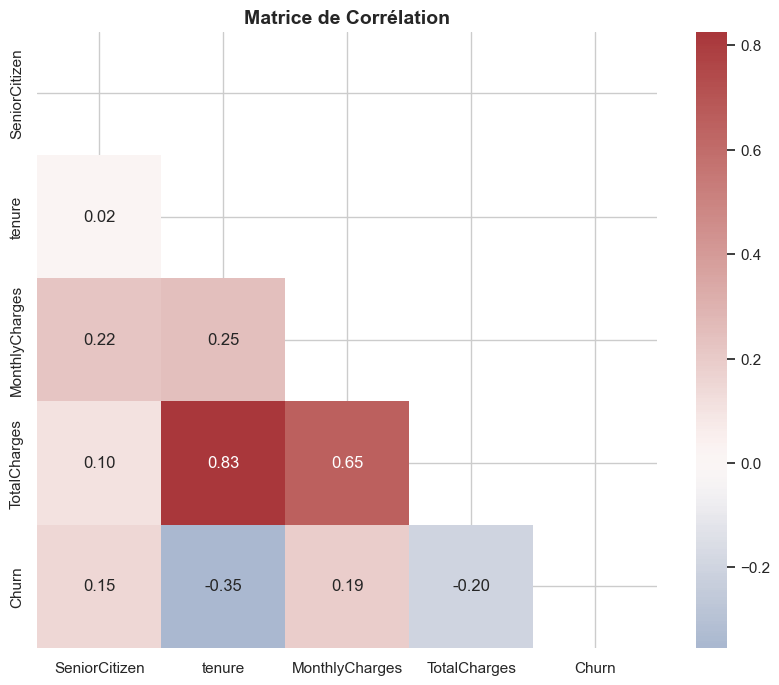

In [11]:
plot_correlation_matrix(df)

**Bilan Financier (Corrélation)**:

 > La matrice confirme avec des chiffres froids nos observations visuelles : une ancienneté forte (Tenure) est fortement corrélée à la fidélité, tandis qu'une facture mensuelle élevée augmente mathématiquement les risques de départ.